In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

# define restricted set of EFPs we will use as features, and thrust which we will use as a label

In [2]:
#EFPs (features x) and thrust (labels y)

def _compute_z_theta_t(events):
    E  = events[..., 0]
    p3 = events[..., 1:4]
    z = 2.0 * E / E.sum(dim=-1, keepdim=True)
    pmag = torch.linalg.norm(p3, dim=-1)
    pdot = torch.einsum('...ia,...ja->...ij', p3, p3)
    denom = pmag.unsqueeze(-1) * pmag.unsqueeze(-2)
    cos_th = torch.where(denom > 0, pdot / denom.clamp_min(1e-30),
                         torch.zeros_like(pdot))
    N = events.shape[-2]
    eye = torch.eye(N, dtype=cos_th.dtype, device=cos_th.device).expand_as(cos_th)
    cos_th = torch.where(eye.bool(), torch.ones_like(cos_th), cos_th)
    return z, 0.5 * (1.0 - cos_th)


def compute_special_torch(events_np, dmax, device='cpu', dtype=torch.float32):
    events = torch.as_tensor(events_np, dtype=dtype, device=device)
    z, th = _compute_z_theta_t(events)
    zz = z.unsqueeze(-1) * z.unsqueeze(-2)

    # powers of theta: Ap[k] = theta^(k+2)
    Ap = [th * th]
    for _ in range(dmax - 2):
        Ap.append(Ap[-1] * th)

    # type 1: sum_ij z_i z_j theta_ij^m
    type1 = torch.stack([(zz * a).sum(dim=(-2, -1)) for a in Ap], dim=-1)

    # s_cache[k] = sum_j z_j theta_ij^(k+2)
    s_cache = [(a * z.unsqueeze(-2)).sum(dim=-1) for a in Ap]
    t2_keys = [(p, q) for p in range(2, dmax + 1)
                      for q in range(p, dmax + 1) if p + q <= dmax]
    type2 = torch.stack([(z * s_cache[p - 2] * s_cache[q - 2]).sum(dim=-1)
                         for p, q in t2_keys], dim=-1)

    # type 3 triangle: for each (s, t) precompute M = A^s @ (diag(z) A^t)
    A = [th]
    for _ in range(dmax - 1):
        A.append(A[-1] * th)
    t3_keys = [(r, s, t) for r in range(1, dmax + 1)
                         for s in range(r, dmax + 1)
                         for t in range(s, dmax + 1) if r + s + t <= dmax]
    M_cache, t3_cols = {}, []
    for r, s, t in t3_keys:
        if (s, t) not in M_cache:
            M_cache[(s, t)] = A[s - 1] @ (z.unsqueeze(-1) * A[t - 1])
        t3_cols.append((zz * A[r - 1] * M_cache[(s, t)]).sum(dim=(-2, -1)))
    type3 = torch.stack(t3_cols, dim=-1)
    return torch.cat([type1, type2, type3], dim=-1)

def compute_thrust(event):
    """Thrust for an e+e- event. event: (N,4) array (E,px,py,pz)."""
    momenta = event[:, 1:4]                      # \vec{p}
    norms = np.linalg.norm(momenta, axis=1)      # |\vec{p}|
    momenta = momenta[norms > 1e-10]             # get rid of 
    norms = norms[norms > 1e-10]                 # particles with 0 norm ... 
    denom = np.sum(norms)                        # sum_i |p_i| 
    best_T = 0.
    for i in range(len(momenta)):                  # only scanning over momenta in the event ...  
        n = momenta[i] / norms[i]                  # \hat{p}
        T = np.sum(np.abs(momenta @ n)) / denom    # sum_i |  |
        if T > best_T:
            best_T = T
    return best_T

## Custom ridge learning-curve function (ridge parameter is called alpha, conventions for scaling with respect to dataset size are from Cengiz's paper

In [3]:
def ridge_learning_curve(X, y, train_sizes, *, n_test=20000, alpha=1e-4,
                         n_repeats=200, scale=True, seed_base=0, verbose=True):
    """Test-MSE learning curve for ridge regression, paper convention.

    Matches Eq. (145) of arXiv:2405.00592v3. The empirical risk is

        L(w) = (1/n) ||X w - y||^2 + alpha ||w||^2,

    stationarity of which gives

        beta = (X^T X + n*alpha I)^{-1} X^T y       (no intercept).

    Predictions are ``pred = X_test @ beta``. When ``alpha == 0`` the function
    falls back to ``np.linalg.lstsq``: ordinary LS for n > p, minimum-norm
    interpolation for n < p.

    The last ``n_test`` rows of (X, y) are held out as the test set; for each
    ``n`` in ``train_sizes``, ``n_repeats`` subsamples of size n are drawn
    without replacement from the rest and fit independently.

    ``scale=True`` standardizes features by the *pool* (mean, std) AND
    subtracts the *pool* mean of y from both pool and test labels. The
    y-centering is the symmetric partner of the X-centering: without it
    ``pred = X_test @ beta`` is forced to have zero mean while y_test is
    not, so MSE would asymptote to ``y_pool.mean()**2`` regardless of alpha
    or n. The std of y is *not* rescaled.

    Parameters
    ----------
    X : array-like, shape (N, p)        features (numpy or torch)
    y : array-like, shape (N,)          labels (numpy or torch)
    train_sizes : sequence of int       training sizes to sweep
    n_test : int                        held-out test rows (taken from the end)
    alpha : float >= 0                  ridge strength (per-sample-loss convention)
    n_repeats : int                     random subsamples per training size
    scale : bool                        standardize X and center y by pool stats
    seed_base : int                     subsample s uses RNG seed seed_base + s
    verbose : bool                      print per-size progress

    Returns
    -------
    sizes : (K,) int ndarray
    mean_mse : (K,) float ndarray
    std_mse  : (K,) float ndarray
    """
    def _to_np(a):
        return a.detach().cpu().numpy() if hasattr(a, "detach") else np.asarray(a)
    X_np = _to_np(X).astype(np.float64, copy=False)
    y_np = _to_np(y).astype(np.float64, copy=False)
    if X_np.ndim != 2 or y_np.ndim != 1 or X_np.shape[0] != y_np.shape[0]:
        raise ValueError(f"X must be (N,p), y must be (N,); got {X_np.shape}, {y_np.shape}")
    if alpha < 0:
        raise ValueError(f"alpha must be >= 0 (got {alpha})")
    N = X_np.shape[0]
    if n_test >= N:
        raise ValueError(f"n_test ({n_test}) >= N ({N})")

    X_pool, y_pool = X_np[:-n_test], y_np[:-n_test]
    X_test, y_test = X_np[-n_test:], y_np[-n_test:]

    if scale:
        mu = X_pool.mean(axis=0)
        sd = X_pool.std(axis=0)
        sd[sd == 0] = 1.0
        X_pool = (X_pool - mu) / sd
        X_test = (X_test - mu) / sd
        # Symmetric partner of X-centering: centering X by the pool mean
        # forces predictions to have zero mean, so y must lose its pool mean
        # too or MSE floors at y_pool.mean()**2.
        y_mu = y_pool.mean()
        y_pool = y_pool - y_mu
        y_test = y_test - y_mu

    p = X_pool.shape[1]
    pool_size = X_pool.shape[0]
    diag_idx = np.arange(p)
    sizes = np.asarray(list(train_sizes), dtype=np.int64)
    mean_mse = np.empty(len(sizes))
    std_mse  = np.empty(len(sizes))

    if verbose:
        mode = "ridgeless (lstsq, min-norm)" if alpha == 0 else f"ridge alpha={alpha:g}"
        print(f"mode: {mode}")
        print(f"{'n':>8}{'mean MSE':>15}{'std MSE':>15}{'time (s)':>12}")

    for k, n in enumerate(sizes):
        if n > pool_size:
            raise ValueError(f"train size {n} > pool size {pool_size}")
        t0 = time.perf_counter()
        losses = np.empty(n_repeats)
        for s in range(n_repeats):
            rng = np.random.default_rng(int(seed_base) + s)
            idx = rng.choice(pool_size, size=n, replace=False)
            X_sub = X_pool[idx]
            y_sub = y_pool[idx]
            if alpha > 0:
                # Paper convention: (X^T X + n*alpha I) beta = X^T y
                G = X_sub.T @ X_sub
                G[diag_idx, diag_idx] += alpha * n
                b = X_sub.T @ y_sub
                beta = np.linalg.solve(G, b)
            else:
                # Ridgeless: SVD pseudoinverse; ordinary LS for n > p,
                # minimum-norm interpolator for n < p.
                beta, *_ = np.linalg.lstsq(X_sub, y_sub, rcond=None)
            pred = X_test @ beta
            losses[s] = np.mean((pred - y_test) ** 2)
        mean_mse[k] = losses.mean()
        std_mse[k]  = losses.std()
        dt = time.perf_counter() - t0
        if verbose:
            print(f"{n:>8d}{mean_mse[k]:>15.6e}{std_mse[k]:>15.6e}{dt:>12.2f}")

    return sizes, mean_mse, std_mse

# import training data: $e^+ e^- \to Z \to q \bar{q}$ at Z pole, segmented by number of branchings 

Below, $N$ refers to total number of final-state particles (so $k$ branchings means $N = k+2$ particles). The file structure is the same as generated by generate_pythia_zqq_splittings.py (here for 100k total events)

In [44]:
Ns = [3,4,8,12,15]

zqq={}
log_EFPs={}
thrust={}

for N in Ns:
    zqq[f'N{N}'] = torch.tensor(np.load(f'pythia_zqq_splittings/splittings_{N-2}.npy'))
    #compute EFPs up to max degree d = 20
    log_EFPs['d20',f'N{N}']= np.log(compute_special_torch(zqq[f'N{N}'],20,device='mps').cpu().numpy())
    #compute labels
    thrust[f'N{N}'] = np.array([compute_thrust(e) for e in zqq[f'N{N}'].numpy()])

In [45]:
log_EFPs['d20','N15'].shape

(20747, 337)

# compute ridge regression with fixed ridge parameter

In [46]:
train_sizes_t = [3, 5, 8, 10, 30, 50, 80, 100, 200, 300, 400, 500, 700, 1000, 2000, 3000, 5000, 8000, 15000]
P={}
mean_mse_thrust={}
std_mse_thrust={}

alphaval = 1e-12

for N in Ns:
        
    _, mean_mse_thrust['d20',f'N{N}'], std_mse_thrust['d20',f'N{N}'] = ridge_learning_curve(
    log_EFPs['d20',f'N{N}'], thrust[f'N{N}'],
    train_sizes=train_sizes_t,
    n_test=5000,
    alpha=alphaval,
    n_repeats=200,
    scale=True
    )

mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
       3   9.055714e-04   3.010949e-03        0.34
       5   3.873769e-04   6.326098e-04        0.48
       8   1.136715e-04   1.265036e-04        0.51
      10   6.147406e-05   6.509814e-05        0.46
      30   1.323698e-05   3.164607e-05        0.45
      50   1.408514e-05   4.183425e-05        0.53
      80   8.984472e-06   1.904756e-05        0.44
     100   8.639966e-06   2.712926e-05        0.46
     200   2.106560e-06   2.864623e-06        0.50
     300   1.033400e-06   1.251423e-06        0.49
     400   7.669539e-07   9.293020e-07        0.78
     500   6.667490e-07   6.277433e-07        0.81
     700   4.959687e-07   4.060767e-07        1.07
    1000   3.195287e-07   2.074435e-07        0.99
    2000   1.964834e-07   5.619787e-08        1.22
    3000   1.633291e-07   2.387657e-08        1.85
    5000   1.472520e-07   1.470843e-08        2.26
    8000   1.383776e-07   8.252904e-09        3.70
   1500

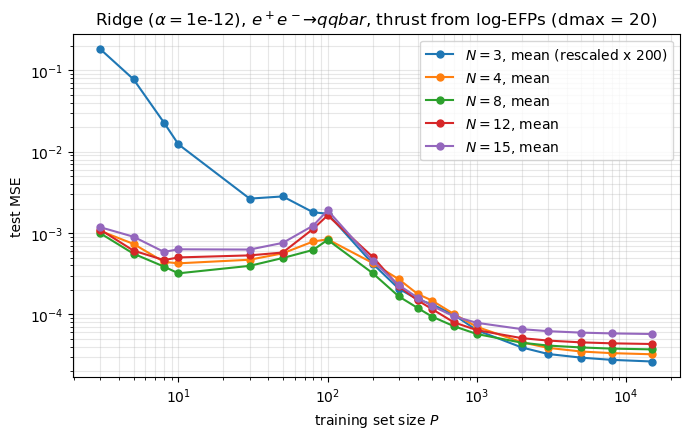

In [54]:
plt.figure(figsize=(7, 4.5))

#rescale N = 3 by hand
plt.plot(train_sizes_t, 200*mean_mse_thrust['d20','N3'],'o-',markersize=5,
             label=r'$N = 3$, mean (rescaled x 200)')
plt.plot(train_sizes_t, mean_mse_thrust['d20','N4'],'o-',markersize=5,
             label=r'$N = 4$, mean')
plt.plot(train_sizes_t, mean_mse_thrust['d20','N8'],'o-',markersize=5,
             label=r'$N = 8$, mean')
plt.plot(train_sizes_t, mean_mse_thrust['d20','N12'],'o-',markersize=5,
             label=r'$N = 12$, mean')
plt.plot(train_sizes_t, mean_mse_thrust['d20','N15'],'o-',markersize=5,
             label=r'$N = 15$, mean')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('training set size $P$')
plt.ylabel('test MSE')
plt.title(rf'Ridge ($\alpha=${alphaval:g}), $e^+ e^- \to qqbar$, thrust from log-EFPs (dmax = 20)')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# approach to loss floor shows a consistent power law across varying number of splittings

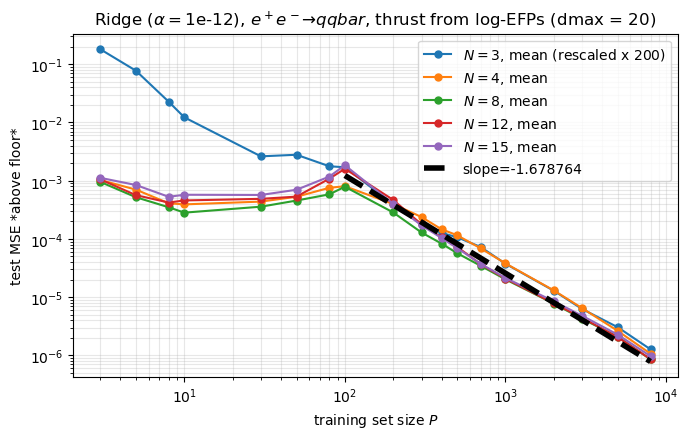

In [53]:
plt.figure(figsize=(7, 4.5))

#rescale N = 3 by hand
plt.plot(train_sizes_t[:-1], 200*(mean_mse_thrust['d20','N3'][:-1]-mean_mse_thrust['d20','N3'][-1]),'o-',markersize=5,
             label=r'$N = 3$, mean (rescaled x 200)')
plt.plot(train_sizes_t[:-1], mean_mse_thrust['d20','N4'][:-1]-mean_mse_thrust['d20','N4'][-1],'o-',markersize=5,
             label=r'$N = 4$, mean')
plt.plot(train_sizes_t[:-1], mean_mse_thrust['d20','N8'][:-1]-mean_mse_thrust['d20','N8'][-1],'o-',markersize=5,
             label=r'$N = 8$, mean')
plt.plot(train_sizes_t[:-1], (mean_mse_thrust['d20','N12'][:-1]-mean_mse_thrust['d20','N12'][-1]),'o-',markersize=5,
             label=r'$N = 12$, mean')
plt.plot(train_sizes_t[:-1], (mean_mse_thrust['d20','N15'][:-1]-mean_mse_thrust['d20','N15'][-1]),'o-',markersize=5,
             label=r'$N = 15$, mean')

slope, log_c = np.polyfit(np.log(train_sizes_t[-12:-1]), np.log(mean_mse_thrust['d20','N12'][-12:-1]-mean_mse_thrust['d20','N12'][-1]), 1)
plt.plot(train_sizes_t[-12:-1],np.exp(log_c)*(train_sizes_t[-12:-1])**(slope),lw=4,linestyle='--',color='k',label=f'slope={slope:3f}')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('training set size $P$')
plt.ylabel('test MSE *above floor*')
plt.title(rf'Ridge ($\alpha=${alphaval:g}), $e^+ e^- \to qqbar$, thrust from log-EFPs (dmax = 20)')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()